# Take-Home Exam C: The Lorenz System

*Submit this notebook with all cells run and all outputs visible. Include written responses in every designated cell. You may use your `myode.py`, numpy, and matplotlib — no other libraries.*

---

## Background

The Lorenz system is a set of three coupled ODEs originally derived to model atmospheric convection:

$$\dot{X} = \sigma(Y - X)$$
$$\dot{Y} = X(\rho - Z) - Y$$
$$\dot{Z} = XY - \beta Z$$

with standard parameters $\sigma = 10$, $\rho = 28$, $\beta = 8/3$.

**Important naming note.** To avoid confusion between the state vector (which we usually call `y`) and the Lorenz variable $Y$, we will call the state vector `u`:

$$\mathbf{u} = [X, Y, Z], \qquad \dot{\mathbf{u}} = [\dot{X}, \dot{Y}, \dot{Z}]$$

The Lorenz system is famous for producing **chaotic** solutions: trajectories are bounded (they don't fly off to infinity) yet never exactly repeat, and infinitesimally close initial conditions diverge exponentially — the *butterfly effect*.


In [1]:
%%writefile myode.py
# myode.py — general-purpose ODE solvers
# Functions accept: f (the diffeq function), y (state vector), dt (timestep)

def move_Euler(f, y, dt):
    ydot = f(y)      # call the passed-in diffeq function
    y    = y + ydot * dt        # Euler update (one line)
    return y

def move_RK2(f, y, dt):
    ydot      = f(y)              # derivatives at time t
    y_half    = y + ydot * dt/2   # propagate to midpoint t + dt/2
    ydot_half = f(y_half)         # evaluate diffeq at midpoint
    y         = y + ydot_half * dt  # update to t + dt
    return y

Overwriting myode.py


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import myode

sigma = 10.0
rho   = 28.0
beta  = 8.0/3.0

# TODO: implement diffeq for the Lorenz system.
# u = [X, Y, Z]
# udot = [sigma*(Y-X),  X*(rho-Z)-Y,  X*Y - beta*Z]

def diffeq(u):
    X, Y, Z = u
    Xdot = sigma*(Y-X)
    Ydot = X*(rho - Z)-Y
    Zdot = X*Y - beta*Z
    return np.array([Xdot, Ydot, Zdot])

## Part 1 — Time Series

Simulate the Lorenz system from $t = 0$ to $t = 50$ using RK2 with $dt = 0.005$. Start from $\mathbf{u}_0 = (1, 1, 1)$.

1. On one figure with two stacked subplots, plot $X(t)$ and $Z(t)$ vs time.
2. Describe the qualitative behavior: is it periodic? Does it repeat? Does it seem to stay bounded?

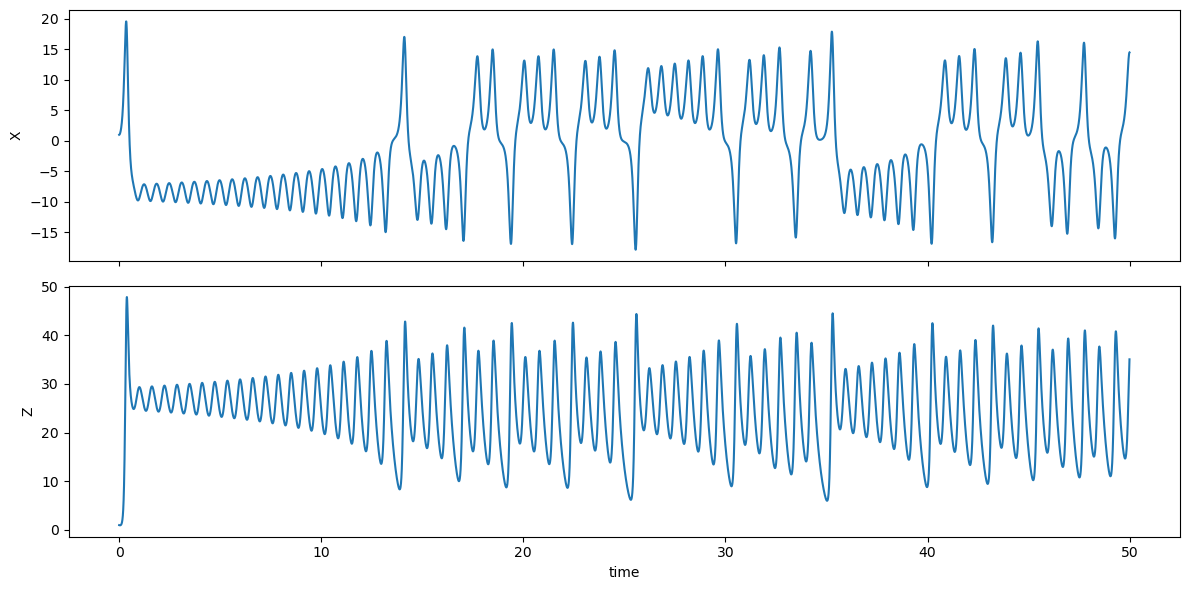

In [3]:
dt = 0.005
t_range = np.arange(0, 50, dt)
u0 = np.array([1.0, 1.0, 1.0])

Xs, Ys, Zs = [], [], []
u = u0.copy()
for t in t_range:
    Xs.append(u[0])
    Ys.append(u[1])
    Zs.append(u[2])

    u = myode.move_RK2(diffeq, u, dt)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
# TODO: plot X(t) and Z(t)
axes[0].set_ylabel('X'); axes[1].set_ylabel('Z')
axes[1].set_xlabel('time')
axes[0].plot(t_range, Xs)
axes[1].plot(t_range, Zs)
plt.tight_layout(); plt.show()

**Written response (Part 1):** Describe the behavior you observe in $X(t)$ and $Z(t)$. Is it periodic? Are the oscillations regular? Does the system appear to be bounded (does it stay within some finite range)?

X(T) and Z(T) are not periodic since they do not repeat in a consistent pattern over time. The peaks and troughs occur at irregular intervals and with varying amplitudes so the motion is not regular.

Yes, both X and Z appear to be within a finite range of values and are bounded.

## Part 2 — The Lorenz Attractor

Make a 3D plot of the trajectory in $(X, Y, Z)$ space.

1. Use `fig = plt.figure(); ax = fig.add_subplot(111, projection='3d')` and `ax.plot(Xs, Ys, Zs, lw=0.3)` to produce the attractor.
2. Also make a 2D projection: plot $X$ vs $Z$ (a flat top-down view of the attractor).
3. The attractor has a characteristic shape — describe it in your written response.

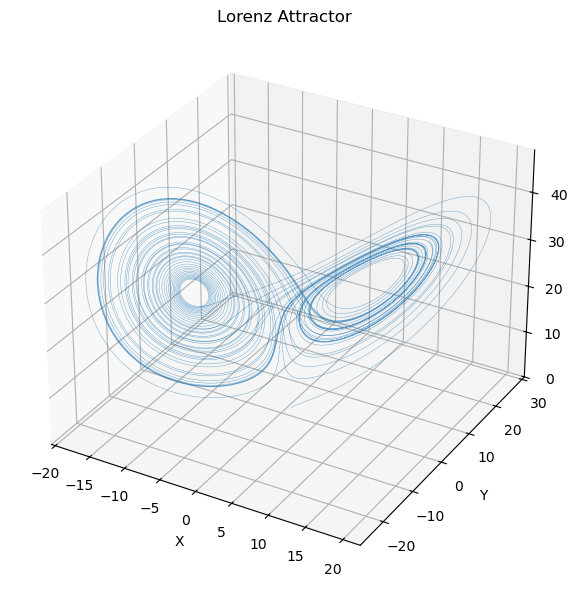

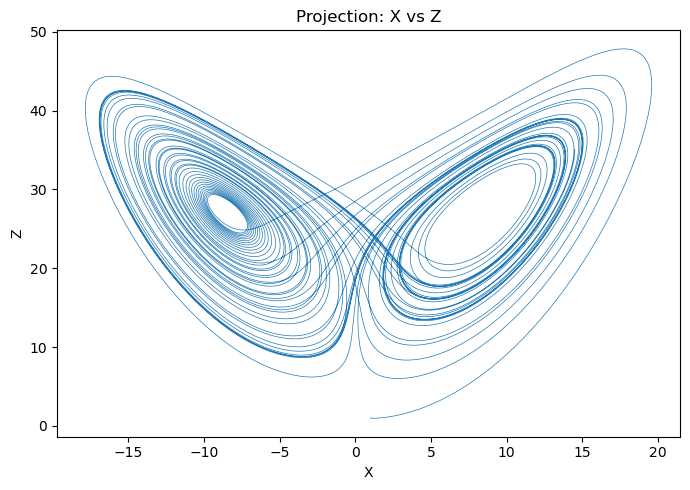

In [4]:
# 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# TODO: ax.plot(Xs, Ys, Zs, lw=0.3, alpha=0.7)

ax.plot(Xs, Ys, Zs, lw=0.3, alpha=0.7)



ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Lorenz Attractor')
plt.tight_layout(); plt.show()

# 2D projection: X vs Z
fig2, ax2 = plt.subplots(figsize=(7, 5))
# TODO: plot X vs Z

ax2.plot(Xs, Zs, lw=0.5)

ax2.set_xlabel('X'); ax2.set_ylabel('Z')
ax2.set_title('Projection: X vs Z')
plt.tight_layout(); plt.show()

**Written response (Part 2):** Describe the shape of the attractor. How many 'lobes' does it have? What does it mean that the trajectory stays on this structure indefinitely without ever exactly repeating?

The attractor has a butterfly like shape with two main lobes. From my observations the trajectory spirals around one lobe and then moves to the other lobe spirals again and repeats this process indefinetly.

## Part 3 — The Butterfly Effect

The Lorenz system is *sensitive to initial conditions*: two trajectories starting very close together will diverge exponentially.

1. Run two trajectories: $\mathbf{u}_0 = (1, 1, 1)$ and $\mathbf{u}_0' = (1 + 10^{-5}, 1, 1)$. Use $dt = 0.005$, $t = 0$ to $50$.
2. Plot the separation $\delta(t) = |\mathbf{u}_1(t) - \mathbf{u}_2(t)|$ vs time on a **semi-log** plot (`ax.semilogy`).
3. At early times ($t < 20$), the growth is approximately exponential: $\delta(t) \approx \delta_0 e^{\lambda t}$. Estimate the Lyapunov exponent $\lambda$ from a linear fit to $\ln(\delta)$ vs $t$ over this early period.

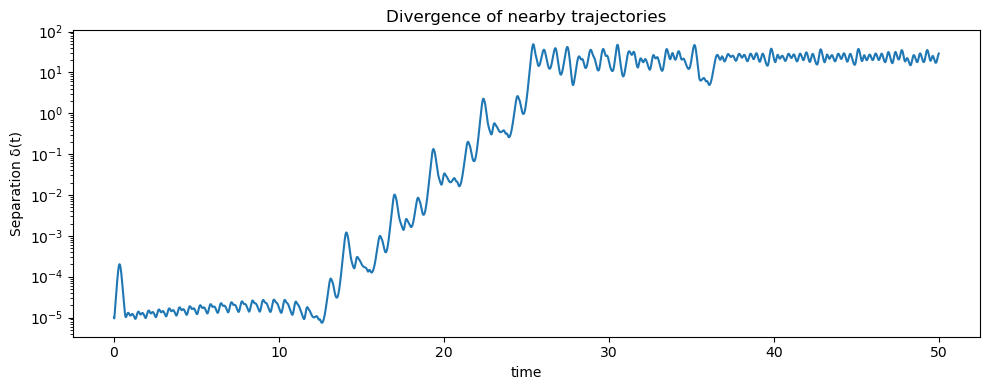

Estimated Lyapunov exponent λ ≈ 0.326


In [5]:
dt = 0.005
t_range = np.arange(0, 50, dt)

u0a = np.array([1.0,       1.0, 1.0])
u0b = np.array([1.0+1e-5,  1.0, 1.0])

# TODO: run both trajectories and compute separation at each step
separations = []
ua, ub = u0a.copy(), u0b.copy()

for t in t_range: 
    delta = np.linalg.norm(ua - ub)
    separations.append(delta)

    ua = myode.move_RK2(diffeq, ua, dt)
    ub = myode.move_RK2(diffeq, ub, dt)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(t_range, separations)
ax.set_xlabel('time'); ax.set_ylabel('Separation δ(t)')
ax.set_title('Divergence of nearby trajectories')
plt.tight_layout(); plt.show()

# Estimate Lyapunov exponent from early-time slope
t_early = t_range[t_range < 20]
log_sep = np.log(separations[:len(t_early)])
lam, _ = np.polyfit(t_early, log_sep, 1)
print(f'Estimated Lyapunov exponent λ ≈ {lam:.3f}')
# (literature value for Lorenz: λ ≈ 0.906)

**Written response (Part 3):** Describe the shape of $\delta(t)$ on the semi-log plot. Is the early growth linear (on a log scale)? Report your estimated $\lambda$ and compare to the accepted value of $\approx 0.906$. What happens to $\delta(t)$ at late times — why does it level off?

The graph initally grows very slowly but then increases rapidly and finally levels off. The growth is linear and does indicate a log scale. The establed lamda is 0.326 which is .6 off from the accepted value. At late times, delta levels off because both trajectories are confined to the lorenz attractor and their distances cannot grow indefinitely. 

## Part 4 — Euler vs. RK2

Use the same initial condition $\mathbf{u}_0 = (1, 1, 1)$ and run to $t = 40$.

1. Simulate with **Euler** at $dt = 0.01$ and **RK2** at $dt = 0.01$.
2. Plot the $X$ vs $Z$ projection for both on the same or side-by-side figures.
3. Now try Euler at $dt = 0.005$. Does that help?

*Note: due to chaos, the exact trajectories will differ even between two good solvers at the same dt. What matters is whether the overall attractor shape is correct.*

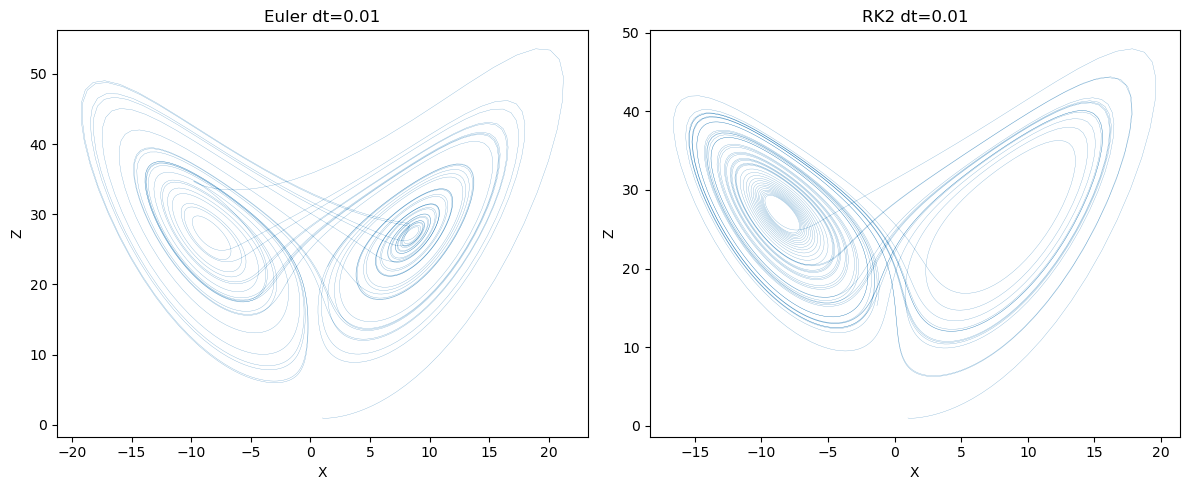

In [6]:
dt = 0.01
t_range = np.arange(0, 40, dt)
u0 = np.array([1.0, 1.0, 1.0])

# Run Euler
Xs_euler, Zs_euler = [], []
u = u0.copy()
# TODO: Euler loop

for t in t_range:
    Xs_euler.append(u[0])
    Zs_euler.append(u[2])
    u = myode.move_Euler(diffeq, u, dt)


# Run RK2
Xs_rk2, Zs_rk2 = [], []
u = u0.copy()
# TODO: RK2 loop

for t in t_range:
    Xs_rk2.append(u[0])
    Zs_rk2.append(u[2])
    u = myode.move_RK2(diffeq, u, dt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(Xs_euler, Zs_euler, lw=0.2, alpha=0.7)
axes[0].set_title('Euler dt=0.01'); axes[0].set_xlabel('X'); axes[0].set_ylabel('Z')
axes[1].plot(Xs_rk2, Zs_rk2, lw=0.2, alpha=0.7)
axes[1].set_title('RK2 dt=0.01'); axes[1].set_xlabel('X'); axes[1].set_ylabel('Z')
plt.tight_layout(); plt.show()

**Written response (Part 4):** Do both methods produce the characteristic two-lobed attractor shape, or does one method fail? If Euler fails, what does the incorrect attractor look like? Why does chaos make it particularly hard to judge the accuracy of a trajectory by direct comparison?

Yes, both methods produce a two-lobed attractor shape. However, Euler is less tightly wound then the RK2 method.

Chaos makes it particularlly hard to judge the accuracy of a trajectory because of small numerical errors which grow exponentially as the functions run. 

## Part 5 — Open-Ended: Varying ρ

The parameter $\rho$ controls whether the system is chaotic. Keep $\sigma = 10$, $\beta = 8/3$ fixed and simulate for several values of $\rho$. For each, run to $t = 60$ from $\mathbf{u}_0 = (1, 1, 1)$ with $dt = 0.005$ and make the $X$ vs $Z$ 2D projection.

Suggested values to try: $\rho = 0.5,\; 5,\; 14,\; 24.06,\; 28,\; 50,\; 99.96$.

1. For each value, describe the long-term behavior: does the trajectory settle to a fixed point, a limit cycle, or a chaotic attractor?
2. Identify approximately the value of $\rho$ above which chaos appears.
3. At $\rho = 99.96$ something qualitatively different happens — describe it.

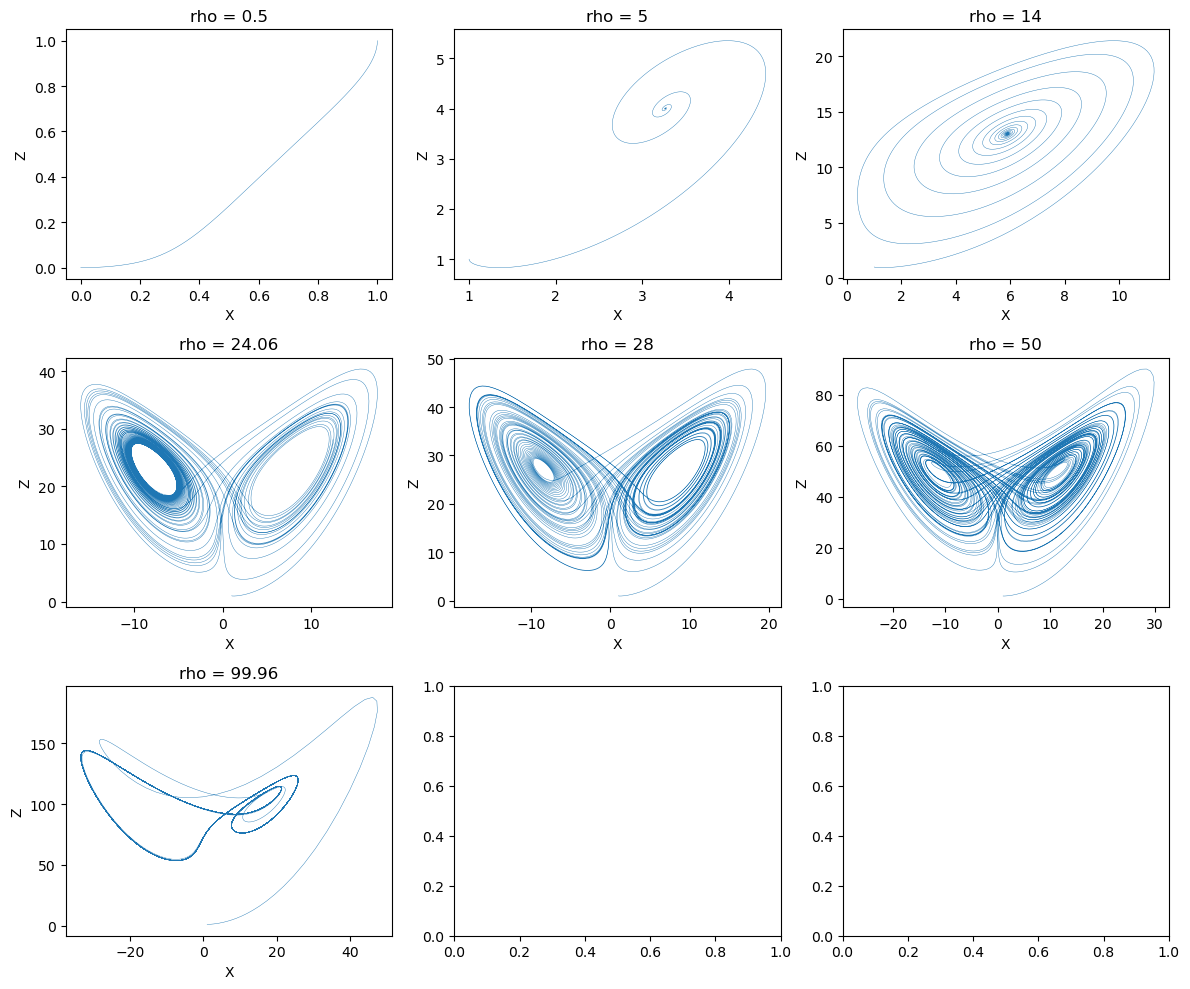

In [7]:
# Part 5 work
dt = 0.005
t_range = np.arange(0, 60, dt)
u0 = np.array([1.0, 1.0, 1.0])

rho_values = [0.5, 5, 14, 24.06, 28, 50, 99.96]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, r in enumerate(rho_values):
    rho = r
    
    Xs, Zs = [], []
    u = u0.copy()
    for t in t_range:
        Xs.append(u[0])
        Zs.append(u[2])
        u = myode.move_RK2(diffeq, u, dt)

    axes[i].plot(Xs, Zs, lw=0.3)
    axes[i].set_title(f"rho = {r}")
    axes[i].set_xlabel("X")
    axes[i].set_ylabel("Z")

plt.tight_layout()
plt.show()

ρ=0.5 : The trajectory approaches a point
p= 5 and 14 : The trajectory spiral's inward (limit cycle)
p = 24.06 : The system begins to transition from a stable behaviour to a more complicated one.
p = 28 : The trajectory now presents chaos with a two loabed structure.
p = 50 : The attractor is still two lobed but is now more "full"
p=99.6 : At this rho the attractor becomes unpredictable that is streaching, curving and switching lobes randomly without forming a circles. This shape is stretched out compared to the other graphs. 

From these graph, the chaos likely begins at rho = 24